In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix, ConfusionMatrixDisplay

In [16]:
data = {
    'hair':     [1,0,0,1,1,1,1,0,0,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,0,1,1,1,1,0,0,1,1,1,1,1,1,0,1,1,1,1,1,1,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1],
    'feathers': [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    'eggs':     [0,1,0,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
    'milk':     [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1],
    'airborne': [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0],
    'aquatic':  [0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,1,0,0,1,0,0,0,0,1,0,0,1,0,1,1,1,1,0,1,1,1,1,1,0,0,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,0,1,1,1,0,0,1,1,0,1,1,0,1,0,0],
    'predator': [1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,1,1,1,1,1,1,1,1,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1,0,1,1,1,0,1,1,0,1,1,1,1,1,1,1,1,0,1,0,1,0,1,1,0,0,1,0,0,0,0,1,0,0,0,0,1,1,1,1,0,1,1,1,1,0,1,1],
    'toothed':  [1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,0,1,1,1,1,1,1,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,0,0,1,1,0,1,0,1,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0],
    'backbone': [1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,0,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,1,1,0,1,0,1,0,1,1,0,0,0,0,0,1,0,0,0,0,0,1],
    'breathes': [1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,1,1,0,0,1,0,1,0,1,0,0,1,1,1,1,1,0,1,1,1,1,1,1],
    'venomous': [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    'fins':     [0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,0,0,1,1,0,1,0,1,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0],
    'legs':     [4,0,4,4,4,4,4,0,0,4,4,4,4,4,4,4,4,4,4,4,6,4,4,4,4,0,4,4,4,4,0,0,2,2,4,4,4,4,0,0,4,4,0,4,4,0,4,4,2,4,2,2,2,2,2,2,2,2,2,2,0,2,2,2,2,2,2,2,2,2,0,0,0,0,0,0,0,0,0,0,0,0,4,0,4,0,4,0,0,6,4,4,4,0,0,6,4,6,4,0,4],
    'tail':     [0,1,1,0,1,1,1,1,1,0,1,0,0,1,0,0,1,1,1,1,0,1,1,1,0,1,1,1,1,1,0,1,0,0,0,1,1,1,0,1,0,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,1,1,0,1,0,1,0,1,1,0,1,1,0,0,1,0,0,0,0,1,0],
    'domestic': [0,0,0,0,0,0,0,0,1,0,0,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,1,0,0,1,0,1,1,1,0,0,0,0,0,1,1,1,0,0,1,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0],
    'catsize':  [1,1,0,1,1,0,1,0,0,0,1,0,0,1,1,0,1,0,1,1,0,0,0,0,1,1,1,0,0,1,0,1,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,0,0,1,1,0,1,0,1,0,1,1,0,0,0,1,0,1,0,0,0,0,0,1],
    'class':    [1,4,2,1,1,2,1,4,1,1,1,1,1,1,1,1,1,1,1,1,7,1,1,1,1,4,1,1,1,1,7,4,1,1,1,1,1,1,4,6,1,1,6,1,1,4,1,1,1,1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,4,4,4,4,4,4,4,4,6,6,4,4,3,4,3,4,5,4,4,3,5,5,1,6,4,3,5,3,5,7,1]
}
Class_name={1:'Mammal', 2:'Bird', 3:'Reptile', 4:'Fish', 5:'Amphibian', 6:'Bug', 7:'Invertebrate'}
df=pd.DataFrame(data)
df['class_name']=df['class'].map(Class_name)
print(f"Shape: {df.shape}")
print(f"\nClass distribution:")
print(df['class_name'].value_counts())

Shape: (101, 18)

Class distribution:
class_name
Mammal          40
Bird            22
Fish            21
Bug              5
Reptile          5
Amphibian        5
Invertebrate     3
Name: count, dtype: int64


In [17]:
df.head()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class,class_name
0,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1,Mammal
1,0,0,1,1,0,0,1,0,0,0,0,1,0,1,0,1,4,Fish
2,0,0,0,1,0,0,1,1,1,1,0,0,4,1,0,0,2,Bird
3,1,0,1,1,0,0,0,1,1,1,0,0,4,0,0,1,1,Mammal
4,1,0,1,1,0,0,1,1,1,1,0,0,4,1,0,1,1,Mammal


In [18]:
X=df.drop(['class', 'class_name'], axis=1)
y=df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape} size\nTest: {X_test.shape} size")

Train: (80, 16) size
Test: (21, 16) size


In [19]:
full_tree=DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)
full_pred=full_tree.predict(X_test)
full_acc=accuracy_score(y_test, full_pred)
print(f"Full Tree Accuracy: {full_acc*100:.3f}%")
print(f"Depth: {full_tree.get_depth()}")
print(f"Leaf Nodes: {full_tree.get_n_leaves()}")


Full Tree Accuracy: 90.476%
Depth: 8
Leaf Nodes: 16


In [20]:
path=full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas=path.ccp_alphas
best_acc,best_alpha,best_tree=0,0,None
for alpha in ccp_alphas:
    t=DecisionTreeClassifier(random_state=42,ccp_alpha=alpha)
    t.fit(X_train,y_train)
    acc = accuracy_score(y_test,t.predict(X_test))
    if acc>=best_acc:
        best_acc,best_alpha,best_tree=acc,alpha,t

pruned_pred = best_tree.predict(X_test)

print(f"Best CCP Alpha     : {best_alpha:.4f}")
print(f"Pruned Tree Accuracy : {best_acc*100:.3f}%")
print(f"Depth              : {best_tree.get_depth()}")
print(f"Leaf Nodes         : {best_tree.get_n_leaves()}")


Best CCP Alpha     : 0.0163
Pruned Tree Accuracy : 90.476%
Depth              : 7
Leaf Nodes         : 9


In [23]:
class_labels=sorted(y.unique())
class_names=[Class_name[c] for c in class_labels]
print("FULL TREE:")
print(classification_report(y_test,full_pred,labels=class_labels,target_names=class_names,zero_division=0))
print("PRUNED TREE")
print(classification_report(y_test,pruned_pred,labels=class_labels,target_names=class_names,zero_division=0))


FULL TREE:
              precision    recall  f1-score   support

      Mammal       1.00      1.00      1.00         8
        Bird       1.00      1.00      1.00         3
     Reptile       1.00      0.50      0.67         2
        Fish       0.80      1.00      0.89         4
   Amphibian       0.00      0.00      0.00         0
         Bug       1.00      1.00      1.00         3
Invertebrate       0.00      0.00      0.00         1

    accuracy                           0.90        21
   macro avg       0.69      0.64      0.65        21
weighted avg       0.91      0.90      0.90        21

PRUNED TREE
              precision    recall  f1-score   support

      Mammal       1.00      1.00      1.00         8
        Bird       1.00      1.00      1.00         3
     Reptile       1.00      0.50      0.67         2
        Fish       0.80      1.00      0.89         4
   Amphibian       0.00      0.00      0.00         0
         Bug       1.00      1.00      1.00         3
I

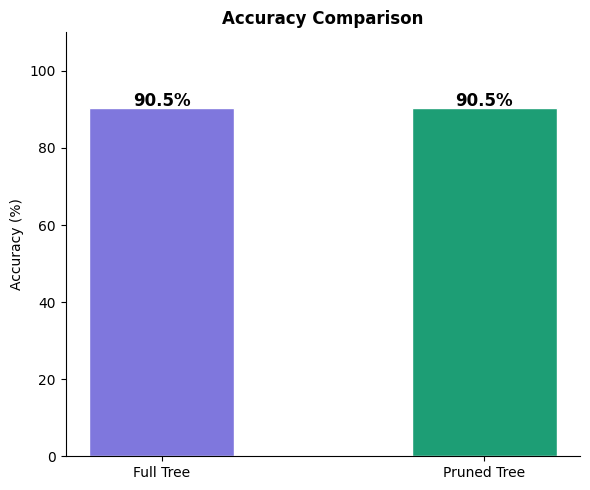

In [25]:
fig,ax=plt.subplots(figsize=(6,5))
PURPLE='#7F77DD'
TEAL='#1D9E75'
bars=ax.bar(['Full Tree','Pruned Tree'],[full_acc*100,best_acc*100],color=[PURPLE,TEAL],width=0.45,edgecolor='white')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.5,f'{bar.get_height():.1f}%',ha='center',fontsize=12,fontweight='bold')
ax.set_ylim(0,110)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy Comparison',fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

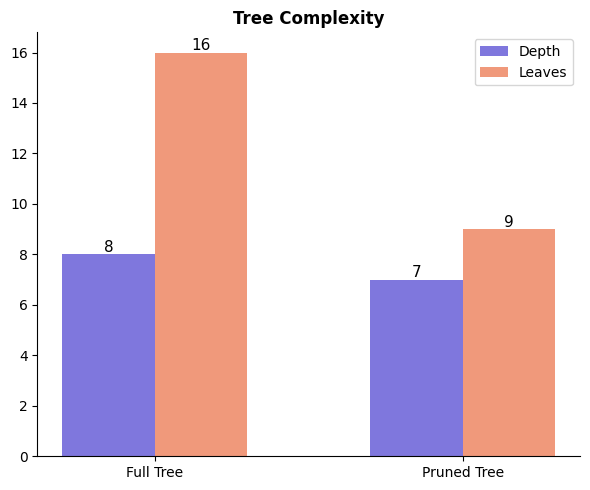

In [27]:
fig,ax=plt.subplots(figsize=(6,5))
PURPLE='#7F77DD'
CORAL='#F0997B'
x=np.arange(2)
w=0.3
b1=ax.bar(x-w/2,[full_tree.get_depth(),best_tree.get_depth()],w,label='Depth',color=PURPLE)
b2=ax.bar(x+w/2,[full_tree.get_n_leaves(),best_tree.get_n_leaves()],w,label='Leaves',color=CORAL)
ax.set_xticks(x)
ax.set_xticklabels(['Full Tree','Pruned Tree'])
ax.legend()
ax.set_title('Tree Complexity',fontweight='bold')
ax.spines[['top','right']].set_visible(False)
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.1,str(int(bar.get_height())),ha='center',fontsize=11)
plt.tight_layout()
plt.show()

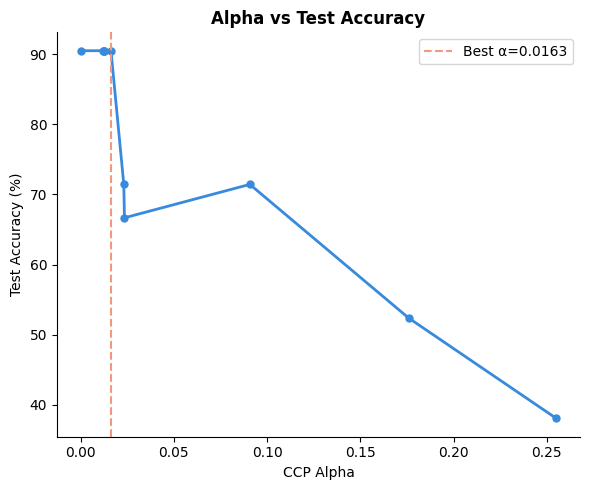

In [28]:
fig,ax=plt.subplots(figsize=(6,5))
BLUE='#378ADD'
CORAL='#F0997B'
test_accs=[]
for alpha in ccp_alphas:
    t=DecisionTreeClassifier(random_state=42,ccp_alpha=alpha)
    t.fit(X_train,y_train)
    test_accs.append(accuracy_score(y_test,t.predict(X_test))*100)
ax.plot(ccp_alphas,test_accs,marker='o',color=BLUE,linewidth=2,markersize=5)
ax.axvline(best_alpha,color=CORAL,linestyle='--',linewidth=1.5,label=f'Best α={best_alpha:.4f}')
ax.set_xlabel('CCP Alpha')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Alpha vs Test Accuracy',fontweight='bold')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

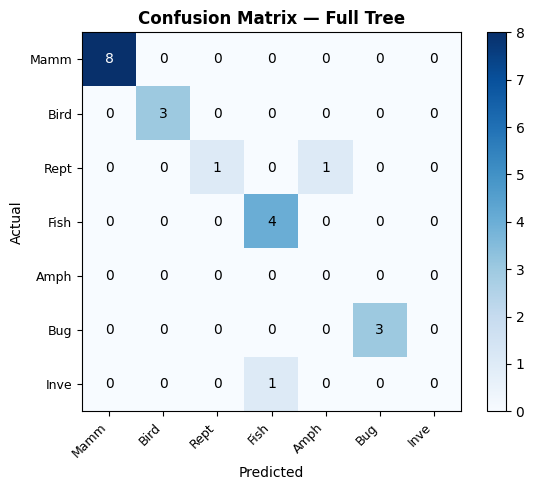

In [30]:
fig,ax=plt.subplots(figsize=(6,5))
cm_full=confusion_matrix(y_test,full_pred,labels=class_labels)
im=ax.imshow(cm_full,cmap='Blues')
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels([c[:4] for c in class_names],rotation=45,ha='right',fontsize=9)
ax.set_yticklabels([c[:4] for c in class_names],fontsize=9)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Full Tree',fontweight='bold')
for i in range(len(class_labels)):
    for j in range(len(class_labels)):
        ax.text(j,i,cm_full[i,j],ha='center',va='center',fontsize=10,color='white' if cm_full[i,j]>cm_full.max()/2 else 'black')
plt.colorbar(im,ax=ax,fraction=0.046)
plt.tight_layout()
plt.show()

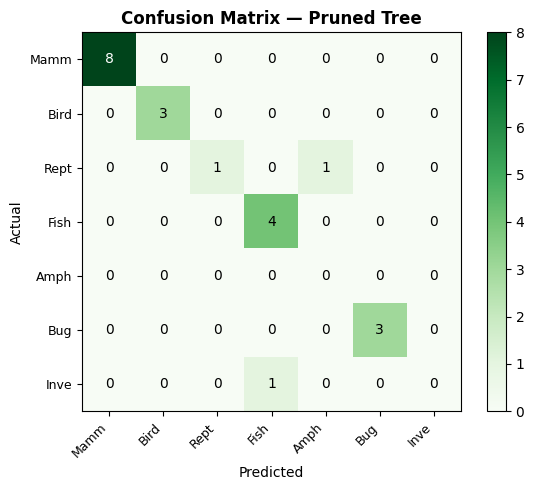

In [31]:
fig,ax=plt.subplots(figsize=(6,5))
cm_pruned=confusion_matrix(y_test,pruned_pred,labels=class_labels)
im=ax.imshow(cm_pruned,cmap='Greens')
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels([c[:4] for c in class_names],rotation=45,ha='right',fontsize=9)
ax.set_yticklabels([c[:4] for c in class_names],fontsize=9)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Pruned Tree',fontweight='bold')
for i in range(len(class_labels)):
    for j in range(len(class_labels)):
        ax.text(j,i,cm_pruned[i,j],ha='center',va='center',fontsize=10,color='white' if cm_pruned[i,j]>cm_pruned.max()/2 else 'black')
plt.colorbar(im,ax=ax,fraction=0.046)
plt.tight_layout()
plt.show()

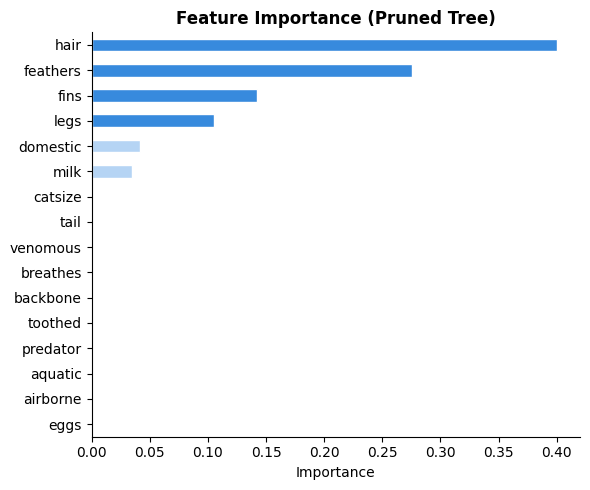

In [33]:
fig,ax=plt.subplots(figsize=(6,5))
BLUE='#378ADD'
fi=pd.Series(best_tree.feature_importances_,index=X.columns).sort_values()
colors_fi=[BLUE if v>0.1 else '#B5D4F4' for v in fi.values]
fi.plot(kind='barh',ax=ax,color=colors_fi,edgecolor='white')
ax.set_xlabel('Importance')
ax.set_title('Feature Importance (Pruned Tree)',fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()